# Lecture 2 — Hands-On Exercises

**CosmicAI Summer School  ·  Data Preparation**

This notebook lets you practice everything from Lecture 2:

* **Impute** missing values (mean, median, mode, KNN)
* **Detect outliers** with Z-score and IQR
* **Scale** numeric features (Standard, MinMax, Robust)
* **Encode** categorical features (Ordinal, One-Hot)
* **Wire it all up** in a scikit-learn Pipeline + ColumnTransformer

You don't need any external data — we use a small synthetic galaxy
catalog defined inline.  Wherever you see `# TODO`, fill in your own
code.  Reference answers are right below each TODO in a click-to-expand
block.


## 1.  Imports


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute        import SimpleImputer, KNNImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler,
                                   RobustScaler,   OrdinalEncoder,
                                   OneHotEncoder)
from sklearn.compose       import ColumnTransformer
from sklearn.pipeline      import Pipeline

np.random.seed(0)
plt.rcParams.update({"figure.figsize": (6, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
print("All imports OK.")


All imports OK.


## 2.  A Tiny Synthetic Galaxy Catalog

We construct a 12-row DataFrame with realistic SDSS-like columns. Note
the deliberately injected missing values  (`NaN`)  and a single big
outlier in the `r_mag` column.


In [2]:
galaxies = pd.DataFrame({
    "galaxy_id":   list(range(1, 13)),
    "morphology":  ["spiral", "elliptical", "spiral",  "irregular",
                    "elliptical", "spiral", "spiral",  np.nan,
                    "irregular", "spiral", "elliptical","spiral"],
    "image_quality":["OK", "excellent", "poor", "OK", "excellent",
                     "OK", "poor", "OK", "OK", "excellent", "OK", "OK"],
    "r_mag":       [18.7, 16.4, 20.1, 21.5, 17.8, 19.2,
                    18.9, np.nan, 20.7, 17.5, 16.9, 28.5],   # ← outlier 28.5
    "g_minus_r":   [0.71, 0.93, 0.42, 0.18, 0.88, 0.65,
                    0.59, 0.74, 0.31, 0.55, 0.95, 0.41],
    "redshift_z":  [0.12, 0.05, 0.28, 0.34, 0.09, 0.18,
                    0.15, 0.11, 0.30, 0.16, 0.08, np.nan],   # ← missing
})
galaxies


,galaxy_id,morphology,image_quality,r_mag,g_minus_r,redshift_z
0,1,spiral,OK,18.7,0.71,0.12
1,2,elliptical,excellent,16.4,0.93,0.05
2,3,spiral,poor,20.1,0.42,0.28
3,4,irregular,OK,21.5,0.18,0.34
4,5,elliptical,excellent,17.8,0.88,0.09
5,6,spiral,OK,19.2,0.65,0.18
6,7,spiral,poor,18.9,0.59,0.15
7,8,NaN,OK,NaN,0.74,0.11
8,9,irregular,OK,20.7,0.31,0.30
9,10,spiral,excellent,17.5,0.55,0.16


## 3.  Exercise 1 — Impute Missing Values

Two columns have NaNs:  `r_mag`  and  `redshift_z`.  Try three different
imputation strategies on a copy of the data and compare.

Order of operations matters:

1. **Mean** imputation.
2. **Median** imputation.
3. **KNN** imputation (n_neighbors=3).


In [3]:
num_cols = ["r_mag", "g_minus_r", "redshift_z"]

X_num = galaxies[num_cols].copy()
print("Before imputation:")
print(X_num)

# Mean imputer
mean_imp   = SimpleImputer(strategy="mean")
X_mean = pd.DataFrame(mean_imp.fit_transform(X_num),  columns=num_cols)

# Median imputer
median_imp = SimpleImputer(strategy="median")
X_median = pd.DataFrame(median_imp.fit_transform(X_num), columns=num_cols)

# KNN imputer
knn_imp    = KNNImputer(n_neighbors=3)
X_knn = pd.DataFrame(knn_imp.fit_transform(X_num),     columns=num_cols)

# Compare the imputed values in the missing rows
for col in num_cols:
    missing_rows = X_num[X_num[col].isna()].index
    if len(missing_rows):
        for row in missing_rows:
            print(f"\n{col}  row {row}:")
            print(f"   mean   imputed = {X_mean.loc[row, col]:.3f}")
            print(f"   median imputed = {X_median.loc[row, col]:.3f}")
            print(f"   KNN    imputed = {X_knn.loc[row, col]:.3f}")


Before imputation:
    r_mag  g_minus_r  redshift_z
0    18.7       0.71        0.12
1    16.4       0.93        0.05
2    20.1       0.42        0.28
3    21.5       0.18        0.34
4    17.8       0.88        0.09
5    19.2       0.65        0.18
6    18.9       0.59        0.15
7     NaN       0.74        0.11
8    20.7       0.31        0.30
9    17.5       0.55        0.16
10   16.9       0.95        0.08
11   28.5       0.41         NaN

r_mag  row 7:
   mean   imputed = 19.655
   median imputed = 18.900
   KNN    imputed = 18.567

redshift_z  row 11:
   mean   imputed = 0.169
   median imputed = 0.150
   KNN    imputed = 0.250


**Observations.**

* For `r_mag`, the row-7 missing value differs noticeably between
  strategies because the outlier `28.5` inflates the mean.
* KNN uses similar galaxies' values, often the most realistic choice.

<details>
<summary><b>Discussion: which imputer would you pick here?</b></summary>

`r_mag` has a clear outlier (28.5).  **Median** or **KNN** would be much
safer than mean.  `redshift_z` has no outlier, so any of the three is
acceptable — KNN is usually the best default because it uses the
multivariate structure.

</details>


## 4.  Exercise 2 — Z-score and IQR Outlier Detection

For the `r_mag` column (after median-imputation), compute:

1. The Z-scores of every row.  Flag any row with `|Z| > 3`.
2. The IQR cutoffs  `Q1 − 1.5·IQR`  and  `Q3 + 1.5·IQR`.  Flag any
   row outside that range.


In [4]:
# Use the median-imputed r_mag for the demo
r = X_median["r_mag"].values

# --- 1. Z-score
mu, sigma = r.mean(), r.std(ddof=0)
z = (r - mu) / sigma
print(f"mean = {mu:.2f}, std = {sigma:.2f}")
print("Z-scores:", np.round(z, 2))

flagged_z = np.where(np.abs(z) > 3)[0]
print(f"Flagged by |Z| > 3 : rows {list(flagged_z)}")
print(f"Note:  the outlier inflates sigma, so |Z| is BELOW 3 here.")
print()

# --- 2. IQR
q1, q3 = np.percentile(r, [25, 75])
iqr    = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
print(f"Q1 = {q1:.2f},  Q3 = {q3:.2f},  IQR = {iqr:.2f}")
print(f"Cutoffs:   [{lo:.2f},  {hi:.2f}]")

flagged_iqr = np.where((r < lo) | (r > hi))[0]
print(f"Flagged by IQR     : rows {list(flagged_iqr)}")


mean = 19.59, std = 3.05
Z-scores: [-0.29 -1.05  0.17  0.63 -0.59 -0.13 -0.23 -0.23  0.36 -0.69 -0.88  2.92]
Flagged by |Z| > 3 : rows []
Note:  the outlier inflates sigma, so |Z| is BELOW 3 here.

Q1 = 17.73,  Q3 = 20.25,  IQR = 2.52
Cutoffs:   [13.94,  24.04]
Flagged by IQR     : rows [np.int64(11)]


**Lesson.**  IQR catches the 28.5 outlier;  the plain Z-score doesn't,
because the same outlier inflated σ enough to mask itself.  This is the
"masking problem" — exactly why we cross-check with IQR.


## 5.  Exercise 3 — Scale the Numeric Features

Compare three scalers on the median-imputed numeric columns.


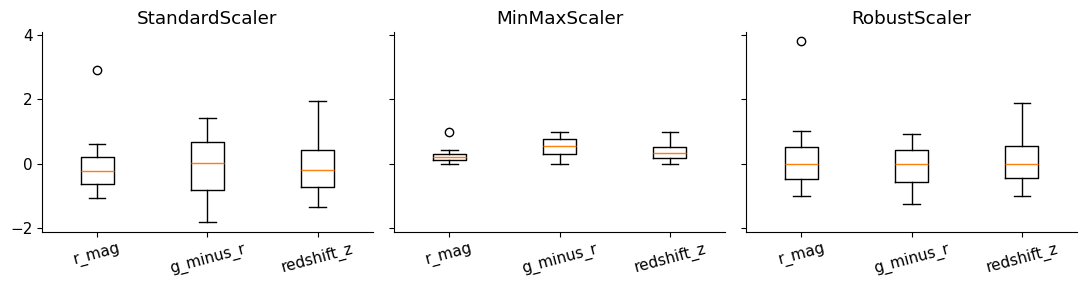

r_mag, scaled:
     raw  standard  minmax  robust
0   18.7     -0.29    0.19   -0.08
1   16.4     -1.05    0.00   -0.99
2   20.1      0.17    0.31    0.48
3   21.5      0.63    0.42    1.03
4   17.8     -0.59    0.12   -0.44
5   19.2     -0.13    0.23    0.12
6   18.9     -0.23    0.21    0.00
7   18.9     -0.23    0.21    0.00
8   20.7      0.36    0.36    0.71
9   17.5     -0.69    0.09   -0.55
10  16.9     -0.88    0.04   -0.79
11  28.5      2.92    1.00    3.80


In [5]:
X = X_median.copy().values

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler":   MinMaxScaler(),
    "RobustScaler":   RobustScaler(),
}

fig, axes = plt.subplots(1, 3, figsize=(11, 3), sharey=True)
for ax, (name, sc) in zip(axes, scalers.items()):
    Xs = sc.fit_transform(X)
    ax.boxplot(Xs, labels=num_cols, vert=True)
    ax.set_title(name); ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

# Show the actual numbers for one column
print("r_mag, scaled:")
print(pd.DataFrame({
    "raw":      X[:, 0],
    "standard": StandardScaler().fit_transform(X)[:, 0].round(2),
    "minmax":   MinMaxScaler().fit_transform(X)[:, 0].round(2),
    "robust":   RobustScaler().fit_transform(X)[:, 0].round(2),
}))


**Observations.**

* `MinMaxScaler` puts everything in `[0, 1]`  — but the outlier 28.5
  squashes the other galaxies near the low end of the scale.
* `StandardScaler` centers on the mean but the outlier still has Z ≈ 3.
* `RobustScaler` uses the median and IQR — it is the most stable when
  outliers are present.

> **Reminder:** Always `.fit()` the scaler on `X_train` only, then
> `.transform()` `X_test`.  Inside a `Pipeline` this happens
> automatically inside every CV fold.


## 6.  Exercise 4 — Encode the Categorical Features

`morphology` is **nominal**;  `image_quality` is **ordinal**.

Apply the right encoder to each column.


In [6]:
# We work on a copy with imputed morphology  ('spiral' is the mode)
cats = galaxies[["morphology", "image_quality"]].copy()
cats["morphology"] = cats["morphology"].fillna("spiral")

# Ordinal — specify the rank explicitly
order = [["poor", "OK", "excellent"]]
ord_enc = OrdinalEncoder(categories=order)
cats["image_quality_ord"] = ord_enc.fit_transform(cats[["image_quality"]])

# One-hot — let it pick the dummies
oh_enc = OneHotEncoder(sparse_output=False)
oh = oh_enc.fit_transform(cats[["morphology"]])
oh_df = pd.DataFrame(oh, columns=oh_enc.get_feature_names_out())

print("Encoded:")
pd.concat([cats[["morphology", "image_quality", "image_quality_ord"]], oh_df], axis=1)


Encoded:


,morphology,image_quality,image_quality_ord,morphology_elliptical,morphology_irregular,morphology_spiral
0,spiral,OK,1.0,0.0,0.0,1.0
1,elliptical,excellent,2.0,1.0,0.0,0.0
2,spiral,poor,0.0,0.0,0.0,1.0
3,irregular,OK,1.0,0.0,1.0,0.0
4,elliptical,excellent,2.0,1.0,0.0,0.0
5,spiral,OK,1.0,0.0,0.0,1.0
6,spiral,poor,0.0,0.0,0.0,1.0
7,spiral,OK,1.0,0.0,0.0,1.0
8,irregular,OK,1.0,0.0,1.0,0.0
9,spiral,excellent,2.0,0.0,0.0,1.0


**Notice** how `image_quality_ord` is `0 < 1 < 2`  — preserving the
ranked order  poor < OK < excellent.   If you had used a one-hot
encoder, you would lose that order.

Conversely, `morphology` becomes three binary indicator columns — the
right choice for a nominal feature.


## 7.  Exercise 5 — Build a Full sklearn Pipeline

Now wire all four steps into one `ColumnTransformer` so the entire
preprocessing happens with one  `fit_transform()`  call.

Pipeline structure:

* **numeric pipeline:**  KNN-impute → RobustScaler
* **ordinal column:**     pass-through after manual encoding
* **nominal column:**     impute most-frequent → one-hot


In [7]:
# Restart from the raw catalog
df = galaxies.copy()
df = df.drop(columns=["galaxy_id"])

num_features = ["r_mag", "g_minus_r", "redshift_z"]
nom_features = ["morphology"]
ord_features = ["image_quality"]

numeric_pipe = Pipeline([
    ("impute", KNNImputer(n_neighbors=3)),
    ("scale",  RobustScaler()),
])
nominal_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("encode", OneHotEncoder(sparse_output=False)),
])
ordinal_pipe = OrdinalEncoder(categories=[["poor", "OK", "excellent"]])

preprocess = ColumnTransformer([
    ("num",  numeric_pipe,  num_features),
    ("nom",  nominal_pipe,  nom_features),
    ("ord",  ordinal_pipe,  ord_features),
])

X_clean = preprocess.fit_transform(df)
print("Final feature matrix shape:", X_clean.shape)
print()
print(np.round(X_clean, 2))


Final feature matrix shape: (12, 7)

[[-0.04  0.25 -0.23  0.    0.    1.    1.  ]
 [-0.95  0.87 -0.69  1.    0.    0.    2.  ]
 [ 0.51 -0.56  0.82  0.    0.    1.    0.  ]
 [ 1.07 -1.23  1.21  0.    1.    0.    1.  ]
 [-0.4   0.73 -0.43  1.    0.    0.    2.  ]
 [ 0.16  0.08  0.16  0.    0.    1.    1.  ]
 [ 0.04 -0.08 -0.03  0.    0.    1.    0.  ]
 [-0.09  0.34 -0.3   0.    0.    1.    1.  ]
 [ 0.75 -0.87  0.95  0.    1.    0.    1.  ]
 [-0.51 -0.2   0.03  0.    0.    1.    2.  ]
 [-0.75  0.92 -0.49  1.    0.    0.    1.  ]
 [ 3.84 -0.59  0.62  0.    0.    1.    1.  ]]


**You just built a real preprocessing pipeline.**

Notice what you got for free:

* A single object  (`preprocess`)  encapsulates the entire workflow.
* You can call  `preprocess.fit(X_train)`  then
  `preprocess.transform(X_test)`  with zero leakage risk.
* Plugging this into a `Pipeline` with a model gives you the
  one-line workflow we'll use in **Lec 4**:
  `Pipeline([("prep", preprocess), ("model", RandomForestRegressor())])`


## 8.  Wrap-Up

You just practiced:

1. Comparing imputation strategies on a column with an outlier
2. Detecting outliers with Z-score and IQR  (and seeing how Z fails)
3. Trying three scalers and picking the right one for outlier-rich data
4. Encoding nominal vs ordinal columns correctly
5. Assembling everything into a single sklearn `ColumnTransformer`

---

**Next up:** Lecture 3a — Data Formatting & Model Reliability
(train/val/test splits, K-fold CV, data leakage).
